In [59]:
# Install Dependencies: fairlearn, catboost, category_encoders, folktables
!pip install fairlearn
!pip install catboost
!pip install category_encoders
!pip install folktables



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [60]:
# Dataset source: project-local CSV (new_dataset.csv), loaded with pandas in the load cell below.
# (Previously this notebook fetched the 2018 ACS Income data via fairlearn.fetch_acs_income;
#  the new dataset is read directly from disk, so no dataset-loader import is needed here.)

In [61]:
# Import Core Libraries: numpy, pandas, matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [62]:
# Import Preprocessing Tools: scalers and transformers
from sklearn.preprocessing import QuantileTransformer, StandardScaler, MinMaxScaler, Normalizer


In [63]:
# Import Algorithms: regression models for baseline comparison
# Ridge, Lasso: L2/L1 regularized linear models
# XGBoost, LightGBM, CatBoost: gradient boosting ensemble models (#)
from sklearn.linear_model import (
    LinearRegression,
    Ridge,  #
    Lasso,  #
    ElasticNet,
    SGDRegressor,
    BayesianRidge,
    ARDRegression
)
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,  #
    ExtraTreesRegressor,
    GradientBoostingRegressor
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor  #
from lightgbm import LGBMRegressor  #
from catboost import CatBoostRegressor  #


In [64]:
# Import Evaluation & Selection Tools: cross-validation, metrics, feature selection
from sklearn.model_selection import cross_val_predict, train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
    explained_variance_score
)
import seaborn as sbn
from sklearn.feature_selection import SelectKBest, mutual_info_regression, f_regression
from sklearn.model_selection import StratifiedShuffleSplit, ShuffleSplit


In [65]:
# Import Boosting Libraries: native xgboost and lightgbm for callbacks and early stopping
import xgboost as xgb
import lightgbm as lgb


In [66]:
# Load Dataset: read the new income dataset from CSV and preview key information
# P1: Inspect sample count, feature count, dtypes, and missing values on initial load
income_df = pd.read_csv("new_dataset.csv")

# --- Quick dataset overview (samples, features, target, missing values) ---
print(f"Samples (rows):  {income_df.shape[0]:,}")
print(f"Columns:         {income_df.shape[1]}  ->  {income_df.shape[1] - 1} features + 1 target ('PINCP')")
print(f"Feature names:   {[c for c in income_df.columns if c != 'PINCP']}")
print(f"Missing values:  {int(income_df.isna().sum().sum())}")
print()

print(income_df.head())
print(income_df.tail())
# no missing records, values are numeric -- info() confirms dtypes + non-null counts
print(income_df.info())

Samples (rows):  210,577
Columns:         10  ->  9 features + 1 target ('PINCP')
Feature names:   ['SEX', 'RELP', 'RAC1P', 'MAR', 'COW', 'SCHL', 'WKHP', 'OCCP', 'AGEP']
Missing values:  0

   SEX  RELP  RAC1P  MAR  COW  SCHL    PINCP  WKHP    OCCP  AGEP
0  1.0   0.0    1.0  5.0  1.0  20.0  44220.0  40.0  2805.0  42.0
1  1.0   0.0    1.0  1.0  6.0  16.0  32702.0  32.0   440.0  62.0
2  2.0   1.0    1.0  1.0  4.0  21.0  50050.0  40.0  2014.0  64.0
3  1.0   0.0    1.0  1.0  1.0  19.0  40001.0  48.0  4710.0  26.0
4  2.0   1.0    3.0  1.0  1.0  19.0  20000.0  40.0  2014.0  24.0
        SEX  RELP  RAC1P  MAR  COW  SCHL    PINCP  WKHP    OCCP  AGEP
210572  2.0   0.0    6.0  5.0  1.0  19.0  25110.0  10.0  4720.0  35.0
210573  1.0   6.0    6.0  1.0  1.0   8.0  92040.0  40.0  6260.0  85.0
210574  2.0   6.0    6.0  1.0  1.0   8.0  13000.0  30.0  4230.0  85.0
210575  1.0   0.0    1.0  1.0  1.0  20.0  80225.0  40.0  4810.0  46.0
210576  2.0   1.0    9.0  1.0  5.0  21.0  50601.0  40.0  4530.0  45.0


50th percentile: $51,502
75th percentile: $87,500
90th percentile: $145,102
95th percentile: $200,005
99th percentile: $425,034
99.9th percentile: $1,103,664


<function matplotlib.pyplot.show(close=None, block=None)>

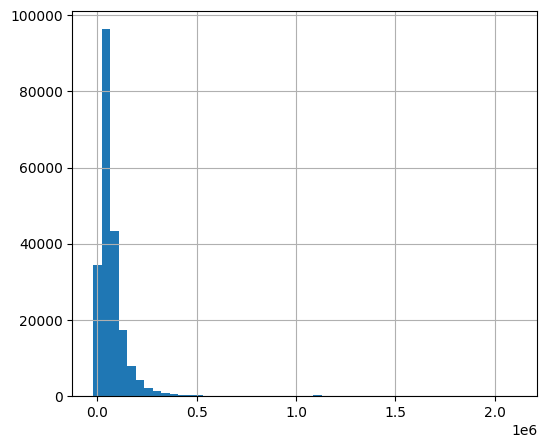

In [67]:
# Graphical: Preview dataset 1 - Analyze outliers in target 'PINCP'
# P2: PINCP income distribution is heavily right-skewed with high-value outliers
for p in [50, 75, 90, 95, 99, 99.9]:
    print(f"{p}th percentile: ${np.percentile(income_df['PINCP'], p):,.0f}")

income_df['PINCP'].hist(figsize=(6,5), bins=50)
plt.show


In [68]:
# Preprocessing 1: Create working copy and remove negative-income outliers
# The new dataset contains a few hundred negative PINCP values (e.g. self-employment losses)
# that are invalid for the log1p target transform applied later, so we drop them here.
income_df_rm_out = income_df[income_df["PINCP"] >= 0].copy()
print(f"Removed {len(income_df) - len(income_df_rm_out)} negative-income rows; "
      f"{len(income_df_rm_out):,} samples remain.")

Removed 199 negative-income rows; 210,378 samples remain.


SCHL   |  15 classes | most common class = 16.0 (26.1% of rows)
MAR    |   5 classes | most common class = 1.0 (56.2% of rows)
OCCP   | 527 classes | most common class = 440.0 (3.5% of rows)
RELP   |  12 classes | most common class = 0.0 (51.2% of rows)
SEX    |   2 classes | most common class = 1.0 (52.6% of rows)
RAC1P  |   6 classes | most common class = 1.0 (77.3% of rows)



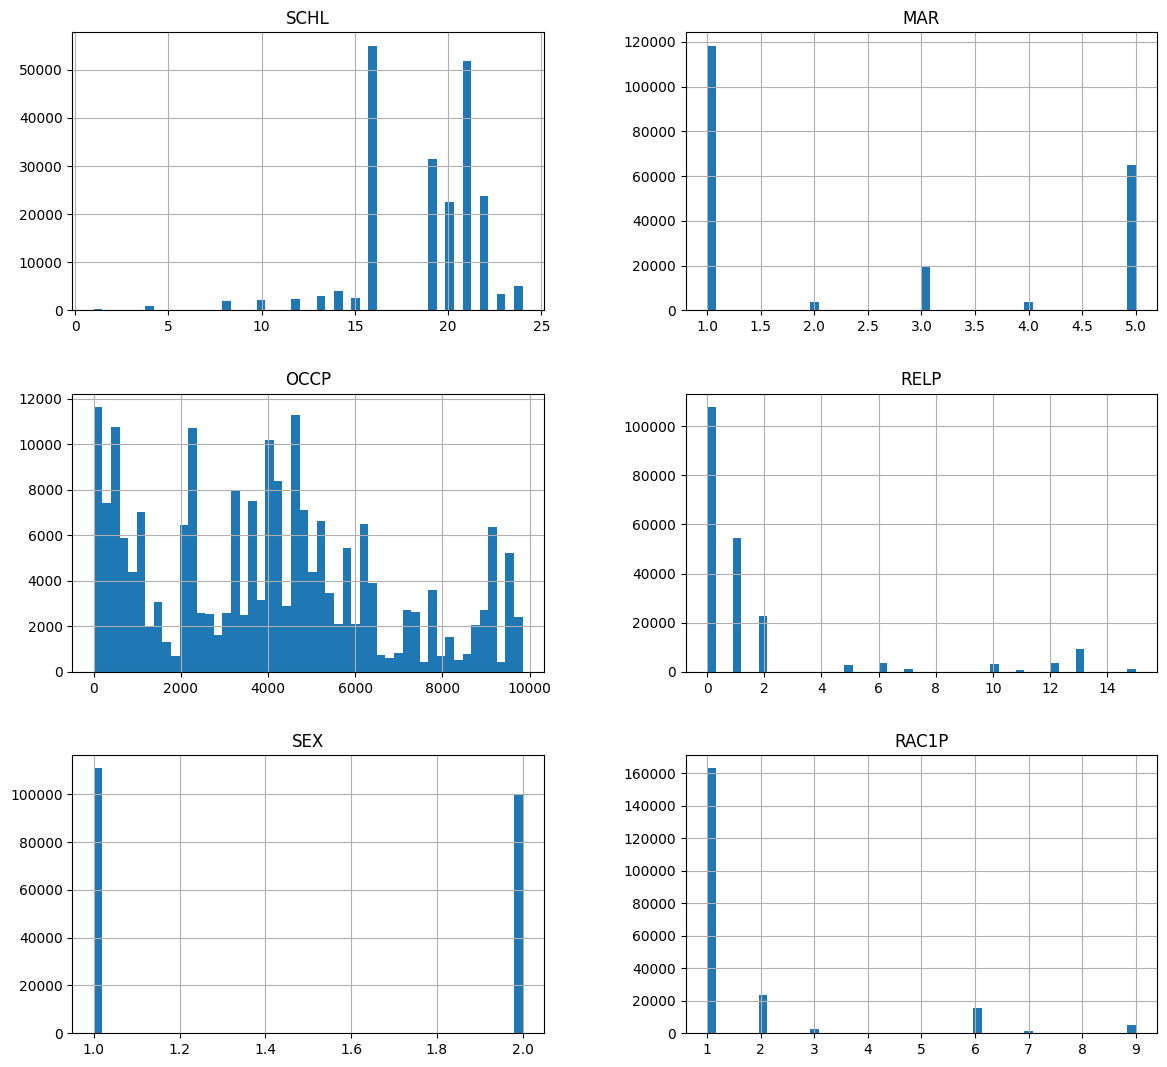

In [69]:
# Graphical: Preview dataset 2 - Class imbalance across categorical features
# P3: SCHL, MAR, OCCP, RELP, SEX, RAC1P show uneven class distributions
# (POBP / place-of-birth from the original 2018 dataset is not present in new_dataset.csv)
cols = ['SCHL', 'MAR', 'OCCP', 'RELP', 'SEX', 'RAC1P']

# Textual class-imbalance summary: number of classes and the dominant class share per feature
for c in cols:
    vc = income_df[c].value_counts(normalize=True)
    print(f"{c:6s} | {income_df[c].nunique():3d} classes | "
          f"most common class = {vc.index[0]} ({vc.iloc[0] * 100:.1f}% of rows)")
print()

income_df[cols].hist(bins=50, figsize=(14, 13))
plt.show()

In [70]:
# Textual: Preview dataset 2 - Confirm working copy and inspect PINCP distribution
print(income_df_rm_out.head())
print(income_df_rm_out.tail())
print(income_df_rm_out['PINCP'].describe())


   SEX  RELP  RAC1P  MAR  COW  SCHL    PINCP  WKHP    OCCP  AGEP
0  1.0   0.0    1.0  5.0  1.0  20.0  44220.0  40.0  2805.0  42.0
1  1.0   0.0    1.0  1.0  6.0  16.0  32702.0  32.0   440.0  62.0
2  2.0   1.0    1.0  1.0  4.0  21.0  50050.0  40.0  2014.0  64.0
3  1.0   0.0    1.0  1.0  1.0  19.0  40001.0  48.0  4710.0  26.0
4  2.0   1.0    3.0  1.0  1.0  19.0  20000.0  40.0  2014.0  24.0
        SEX  RELP  RAC1P  MAR  COW  SCHL    PINCP  WKHP    OCCP  AGEP
210572  2.0   0.0    6.0  5.0  1.0  19.0  25110.0  10.0  4720.0  35.0
210573  1.0   6.0    6.0  1.0  1.0   8.0  92040.0  40.0  6260.0  85.0
210574  2.0   6.0    6.0  1.0  1.0   8.0  13000.0  30.0  4230.0  85.0
210575  1.0   0.0    1.0  1.0  1.0  20.0  80225.0  40.0  4810.0  46.0
210576  2.0   1.0    9.0  1.0  5.0  21.0  50601.0  40.0  4530.0  45.0
count    2.103780e+05
mean     7.423314e+04
std      9.232053e+04
min      0.000000e+00
25%      3.000000e+04
50%      5.160500e+04
75%      8.751175e+04
max      2.108379e+06
Name: PINCP, d

In [71]:
# Preprocessing 2: Create second working copy for group-level categorical encoding
income_df_rm_out_group = income_df_rm_out.copy()


In [72]:
# Textual: Preview SEX feature distribution
print(income_df_rm_out_group['SEX'].value_counts())


SEX
1.0    110618
2.0     99760
Name: count, dtype: int64


In [73]:
# Textual: Preview COW (Class of Worker) feature distribution
print(income_df_rm_out['COW'].value_counts())


COW
1.0    157610
3.0     13214
6.0     12660
4.0     10874
7.0      8378
5.0      7550
8.0        92
Name: count, dtype: int64


In [74]:
# Fix P3a: Group RAC1P (race codes) into readable string categories
# RAC1P numeric codes -> 'white', 'black', 'asian', 'indigenous', 'pacific', 'other', 'multi'
def map_race(x):
    if x == 1:
        return "white"
    elif x == 2:
        return "black"
    elif x == 6:
        return "asian"
    elif x in [3, 4, 5]:
        return "indigenous"
    elif x == 7:
        return "pacific"
    elif x == 8:
        return "other"
    elif x == 9:
        return "multi"
    else:
        return "unknown"

income_df_rm_out_group["RAC1P_GROUP"] = income_df_rm_out["RAC1P"].apply(map_race)
income_df_rm_out = income_df_rm_out.dropna(subset=['RAC1P'])
income_df_rm_out_group = income_df_rm_out_group.dropna(subset=['RAC1P_GROUP'])

print(income_df_rm_out['RAC1P'].value_counts())
print(income_df_rm_out_group['RAC1P_GROUP'].value_counts())

income_df_rm_out_group.drop('RAC1P', axis=1, inplace=True)


RAC1P
1.0    162696
2.0     23232
6.0     15436
9.0      4940
3.0      2815
7.0      1259
Name: count, dtype: int64
RAC1P_GROUP
white         162696
black          23232
asian          15436
multi           4940
indigenous      2815
pacific         1259
Name: count, dtype: int64


In [75]:
# Fix P3b: Group RELP (relationship codes) into household-role categories
# RELP codes -> 'reference', 'spouse', 'child_dep', 'parent', 'extended_family', 'non_family', 'other', 'group_quarters'
def map_relp(x):
    if x == 0:
        return "reference"
    elif x == 1:
        return "spouse"
    elif x in [2, 3, 4, 7, 14]:
        return "child_dep"
    elif x in [6, 8]:
        return "parent"
    elif x in [5, 9, 10]:
        return "extended_family"
    elif x in [11, 12, 13]:
        return "non_family"
    elif x == 15:
        return "other"
    elif x in [16, 17]:
        return "group_quarters"
    else:
        return "unknown"


income_df_rm_out_group["RELP_GROUP"] = income_df_rm_out["RELP"].apply(map_relp)
income_df_rm_out = income_df_rm_out.dropna(subset=['RELP'])
income_df_rm_out_group = income_df_rm_out_group.dropna(subset=['RELP_GROUP'])

print(income_df_rm_out['RELP'].value_counts())
print(income_df_rm_out_group['RELP_GROUP'].value_counts())

income_df_rm_out_group.drop('RELP', axis=1, inplace=True)


RELP
0.0     107662
1.0      54486
2.0      22654
13.0      9150
12.0      3611
6.0       3523
10.0      3342
5.0       2829
7.0       1218
15.0      1207
11.0       655
14.0        41
Name: count, dtype: int64
RELP_GROUP
reference          107662
spouse              54486
child_dep           23913
non_family          13416
extended_family      6171
parent               3523
other                1207
Name: count, dtype: int64


In [76]:
# Fix P3c (Not applicable to the new dataset):
# The original 2018 ACS dataset included POBP (place of birth), which was grouped here into
# continental / regional buckets. new_dataset.csv does NOT include a POBP column, so this
# grouping step is no longer needed and is intentionally left as a no-op.

In [77]:
# Fix P3d: Group SCHL (education codes 1-24) into 6 ordinal education tiers
# 1=Less than HS, 2=HS/GED, 3=Some college, 4=Associate, 5=Bachelor, 6=Graduate+
#SCHL
def map_school(s):
    if 1 <= s <= 15:
        return 1.0   # Less than HS
    elif s in [16, 17]:
        return 2.0   # HS or GED
    elif s in [18, 19]:
        return 3.0   # Some college
    elif s == 20:
        return 4.0  # Associate
    elif s == 21:
        return 5.0   # Bachelor
    elif 22 <= s <= 24:
        return 6.0   # Graduate+
    else:
        return 7.0 #other
print(income_df_rm_out['SCHL'].value_counts())
income_df_rm_out_group['SCHL'] = income_df_rm_out['SCHL'].apply(map_school)
print(income_df_rm_out_group['SCHL'].value_counts())


SCHL
16.0    54963
21.0    51860
19.0    31482
22.0    23668
20.0    22560
24.0     5103
14.0     4095
23.0     3373
13.0     2998
15.0     2639
12.0     2403
10.0     2078
8.0      2025
4.0       834
1.0       297
Name: count, dtype: int64
SCHL
2.0    54963
5.0    51860
6.0    32144
3.0    31482
4.0    22560
1.0    17369
Name: count, dtype: int64


In [78]:
# Fix P3e: Group OCCP (occupation codes) into 26 industry-standard abbreviations
# e.g. MGR=Management, ENG=Engineering, MED=Medical, TRN=Transportation, MIL=Military
import numpy as np
import pandas as pd

def map_occp_group(code):
    if pd.isna(code):
        return np.nan

    code = int(code)

    if 10 <= code <= 440:
        return "MGR"
    elif 500 <= code <= 750:
        return "BUS"
    elif 800 <= code <= 960:
        return "FIN"
    elif 1005 <= code <= 1240:
        return "CMM"
    elif 1305 <= code <= 1560:
        return "ENG"
    elif 1600 <= code <= 1980:
        return "SCI"
    elif 2001 <= code <= 2060:
        return "CMS"
    elif 2100 <= code <= 2180:
        return "LGL"
    elif 2205 <= code <= 2555:
        return "EDU"
    elif 2600 <= code <= 2920:
        return "ENT"
    elif 3000 <= code <= 3550:
        return "MED"
    elif 3601 <= code <= 3655:
        return "HLS"
    elif 3700 <= code <= 3960:
        return "PRT"
    elif 4000 <= code <= 4160:
        return "EAT"
    elif 4200 <= code <= 4255:
        return "CLN"
    elif 4330 <= code <= 4655:
        return "PRS"
    elif 4700 <= code <= 4965:
        return "SAL"
    elif 5000 <= code <= 5940:
        return "OFF"
    elif 6005 <= code <= 6130:
        return "FFF"
    elif 6200 <= code <= 6765:
        return "CON"
    elif 6800 <= code <= 6950:
        return "EXT"
    elif 7000 <= code <= 7640:
        return "RPR"
    elif 7700 <= code <= 8990:
        return "PRD"
    elif 9005 <= code <= 9760:
        return "TRN"
    elif 9800 <= code <= 9830:
        return "MIL"
    elif code == 9920:
        return "UNEMP"
    else:
        return np.nan

income_df_rm_out_group["OCCP_GROUP"] = income_df_rm_out["OCCP"].apply(map_occp_group)
income_df_rm_out = income_df_rm_out.dropna(subset=['OCCP'])
income_df_rm_out_group = income_df_rm_out_group.dropna(subset=['OCCP_GROUP'])

print(income_df_rm_out['OCCP'].value_counts())
print(income_df_rm_out_group['OCCP_GROUP'].value_counts())

income_df_rm_out_group.drop('OCCP', axis=1, inplace=True)


OCCP
440.0     7419
2310.0    4847
9130.0    4637
3255.0    4522
4700.0    3988
          ... 
7730.0       9
3900.0       8
8910.0       7
8940.0       4
5040.0       3
Name: count, Length: 527, dtype: int64
OCCP_GROUP
MGR    26927
OFF    20756
SAL    18213
TRN    15291
MED    13366
EDU    13059
CON    11358
PRD    11085
EAT    10579
CMM     7760
CLN     7570
BUS     7362
HLS     6785
RPR     6498
PRS     5046
FIN     4404
ENG     4370
ENT     4119
PRT     3898
CMS     3776
SCI     2479
LGL     2451
FFF     1550
EXT      324
Name: count, dtype: int64


In [79]:
# Textual: Preview dataset 3 - Confirm final schema after all grouping transformations
print(income_df_rm_out_group.info())


<class 'pandas.DataFrame'>
Index: 209026 entries, 0 to 210576
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   SEX          209026 non-null  float64
 1   MAR          209026 non-null  float64
 2   COW          209026 non-null  float64
 3   SCHL         209026 non-null  float64
 4   PINCP        209026 non-null  float64
 5   WKHP         209026 non-null  float64
 6   AGEP         209026 non-null  float64
 7   RAC1P_GROUP  209026 non-null  str    
 8   RELP_GROUP   209026 non-null  str    
 9   OCCP_GROUP   209026 non-null  str    
dtypes: float64(7), str(3)
memory usage: 20.9 MB
None


In [80]:
# Encoding 1: OrdinalEncoder for RELP_GROUP (household role -> income proxy order)
# Order reflects expected income contribution: group_quarters(lowest) -> reference(primary earner)
from sklearn.preprocessing import OrdinalEncoder

relp_order = [[
    'group_quarters',   # least typical income structure
    'child_dep',            # dependents
    'unknown',
    'parent',           # often retired
    'other',            # unclear
    'extended_family',
    'non_family',       # roommates / partners
    'spouse',           # secondary earner
    'reference'         # primary earner
]]

ordinal_relp = OrdinalEncoder(categories=relp_order)

income_df_rm_out_group['RELP_GROUP'] = ordinal_relp.fit_transform(
    income_df_rm_out_group[['RELP_GROUP']]
)


In [81]:
# Encoding 2: OrdinalEncoder for RAC1P_GROUP (race group -> ordinal numeric)
# NB: Order is non-prescriptive; used only to supply a numeric representation for tree-based models
race_order = [[
    'indigenous',
    'pacific',
    'black',
    'other',
    'multi',
    'white',
    'asian'
]]

ordinal_race = OrdinalEncoder(categories=race_order)

income_df_rm_out_group['RAC1P_GROUP'] = ordinal_race.fit_transform(
    income_df_rm_out_group[['RAC1P_GROUP']]
)


In [82]:
# Encoding 3: OrdinalEncoder for OCCP_GROUP (occupation group -> float values)
# 26 industry categories encoded to [0.0, 25.0]; used as ordered numeric input
#encode to float values
ordinal = OrdinalEncoder(categories=[[
    'MGR', 'BUS', 'FIN', 'CMM', 'ENG', 'SCI', 'CMS', 'LGL', 'EDU',
    'ENT', 'MED', 'HLS', 'PRT', 'EAT', 'CLN', 'PRS', 'SAL', 'OFF',
    'FFF', 'CON', 'EXT', 'RPR', 'PRD', 'TRN', 'MIL', 'UNEMP'
]])

income_df_rm_out_group['OCCP_GROUP'] = ordinal.fit_transform(
    income_df_rm_out_group[['OCCP_GROUP']]
)


In [83]:
# Encoding 4: One-Hot Encode OCCP_GROUP, MAR, RELP_GROUP, RAC1P_GROUP
# One hot encode categorical variables
# Adjust this encoding for n-1 variables to account for
# multi-collinearity; the dropped variable becomes the baseline
income_df_rm_out_group_onehot = pd.get_dummies(
    income_df_rm_out_group,
    columns=['OCCP_GROUP', 'MAR', 'RELP_GROUP', 'RAC1P_GROUP'],
    prefix=['OCCP_GROUP', 'MAR', 'RELP_GROUP', 'RAC1P_GROUP'],
    dtype=float   #  forces 1.0 / 0.0
)
'''
income_df_rm_out_group_onehot_mc = pd.get_dummies(
    income_df_rm_out_group,
    columns=['OCCP_GROUP', 'MAR', 'RELP_GROUP', 'RAC1P_GROUP', 'SCHL'],
    prefix=['OCCP_GROUP', 'MAR', 'RELP_GROUP', 'RAC1P_GROUP', 'SCHL'],
    dtype=float,
    drop_first=True  # drop_first=True: removes one dummy per group to avoid multi-collinearity
)
'''


"\nincome_df_rm_out_group_onehot_mc = pd.get_dummies(\n    income_df_rm_out_group,\n    columns=['OCCP_GROUP', 'MAR', 'RELP_GROUP', 'RAC1P_GROUP', 'SCHL'],\n    prefix=['OCCP_GROUP', 'MAR', 'RELP_GROUP', 'RAC1P_GROUP', 'SCHL'],\n    dtype=float,\n    drop_first=True  # drop_first=True: removes one dummy per group to avoid multi-collinearity\n)\n"

In [84]:
# Persist Preprocessed Data: Save one-hot and grouped dataframes to parquet (run once)
# Run this cell once after completing the preprocessing steps (cells 7-24).
# It saves two dataframes to disk as parquet files:
#   - preprocessed_onehot.parquet: one-hot encoded dataframe used for income_X and income_y
#   - preprocessed_group.parquet: grouped/encoded dataframe used for feature generation and visualizations
# This avoids having to re-run all the slow preprocessing steps on future sessions.
income_df_rm_out_group_onehot.to_parquet("preprocessed_onehot.parquet", index=False, engine="fastparquet")
income_df_rm_out_group.to_parquet("preprocessed_group.parquet", index=False, engine="fastparquet")
print("Saved preprocessed data to disk.")


Saved preprocessed data to disk.


In [85]:
# Fast Path: Load Preprocessed Data from parquet (skips cells 7-24 on future sessions)
# On future sessions, run the import cells (0-6) then run this cell
# instead of re-running cells 7-24. This loads the saved parquet files
# back into memory and restores the two dataframes needed for the rest of the notebook.
# After running this, continue from the next cell onward as normal.
# NOTE: You must have run the save cell at least once before using this.
income_df_rm_out_group_onehot = pd.read_parquet("preprocessed_onehot.parquet", engine="fastparquet")
income_df_rm_out_group = pd.read_parquet("preprocessed_group.parquet", engine="fastparquet")
print(f"Loaded: {income_df_rm_out_group_onehot.shape}, {income_df_rm_out_group.shape}")


Loaded: (209026, 48), (209026, 10)


In [86]:
# Feature Identification: Select Active Dataset Variant for income_X and income_y
# Commented-out blocks show alternative preprocessing paths:
#   - raw income_df: no outlier removal, no grouping
#   - income_df_rm_out: outliers removed only
#   - income_df_rm_out_group: grouped categories, no one-hot
# Active path: fully preprocessed one-hot encoded dataframe
#Select what modifications to go through with
'''
income_X = income_df.drop(["PINCP"], axis=1);
income_y = income_df["PINCP"].copy();
'''
'''
income_X = income_df_rm_out.drop(["PINCP"], axis=1);
income_y = income_df_rm_out["PINCP"].copy();
'''
'''
income_X = income_df_rm_out_group.drop(["PINCP"], axis=1);
income_y = income_df_rm_out_group["PINCP"].copy();
'''


income_X = income_df_rm_out_group_onehot.drop(["PINCP"], axis=1);
income_y = income_df_rm_out_group_onehot["PINCP"].copy();


In [87]:
# Feature Engineering -> Feature Generation: Interaction terms for continuous features
# Combining AGEP(age), WKHP(hrs/week), SCHL(education) as multiplicative interaction features
# Non-linearization via squaring commented out but preserved for experimentation
#Feature Generation
#there are 3 regression variables that can be combined: AGEP, WKHP, SCHL
income_X_feat = income_df_rm_out_group.drop(["PINCP"], axis=1);
income_X_feat['WKHPxAGEP'] = income_X['WKHP'] * income_X['AGEP']
income_X_feat['WKHPxSCHL'] = income_X['WKHP'] * income_X['SCHL']
income_X_feat['AGEPxSCHL'] = income_X['AGEP'] * income_X['SCHL']

#non-linearize
#income_X_feat['AGEP2'] = income_X['AGEP'] ** 2
#income_X_feat['WKHP2'] = income_X['WKHP'] ** 2

#income_X_feat.drop(['WKHP', 'POBP'], axis=1, inplace=True)


In [88]:
# Textual: Confirm target shape after feature/target split
print(income_y.shape)


(209026,)


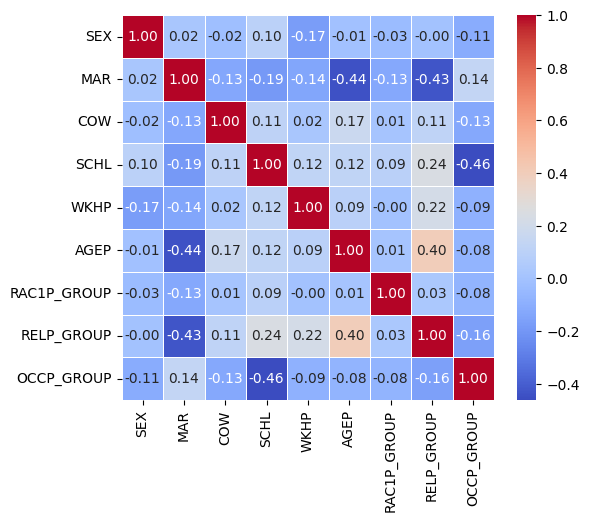

In [89]:
# Graphical: Feature Selection 1 - Pearson correlation heatmap across all grouped features
# High +/-ve correlation to PINCP -> relevant; near-0 -> irrelevant
vis_feats_X = income_df_rm_out_group.loc[:, :]
vis_feats_X.drop(['PINCP'], axis=1, inplace = True)
vis_feats_corr = vis_feats_X.corr('pearson')
plt.figure(figsize=(6,5))
sbn.heatmap(vis_feats_corr, annot=True, linewidths=0.5, fmt='.2f', cmap='coolwarm')
plt.show()


In [90]:
# Feature Engineering -> Feature Selection: SelectKBest with mutual_info_regression (Non-Linear)
# mutual_info_regression: Nonlinear correlation to target; k=10 selects top-10 features
KBest = SelectKBest(score_func=mutual_info_regression, k=10)
output = KBest.fit_transform(income_X_feat, income_y)
top_feats_X = pd.DataFrame(output, columns=KBest.get_feature_names_out())

print(top_feats_X.head())
print(KBest.get_feature_names_out())


   SEX  MAR  SCHL  WKHP  AGEP  RELP_GROUP  OCCP_GROUP  WKHPxAGEP  WKHPxSCHL  \
0  1.0  5.0   4.0  40.0  42.0         8.0         9.0     1680.0      160.0   
1  1.0  1.0   2.0  32.0  62.0         8.0         0.0     1984.0       64.0   
2  2.0  1.0   5.0  40.0  64.0         7.0         6.0     2560.0      200.0   
3  1.0  1.0   3.0  48.0  26.0         8.0        16.0     1248.0      144.0   
4  2.0  1.0   3.0  40.0  24.0         7.0         6.0      960.0      120.0   

   AGEPxSCHL  
0      168.0  
1      124.0  
2      320.0  
3       78.0  
4       72.0  
['SEX' 'MAR' 'SCHL' 'WKHP' 'AGEP' 'RELP_GROUP' 'OCCP_GROUP' 'WKHPxAGEP'
 'WKHPxSCHL' 'AGEPxSCHL']


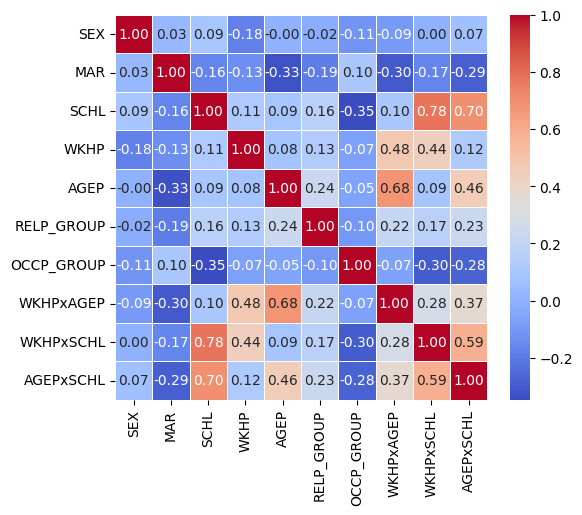

In [91]:
# Graphical: Feature Selection 2 - Kendall correlation heatmap on top-10 selected features
# Kendall(nonlinear): Identifies multi-collinearity/redundancy to eliminate before training
vis_feats_X = top_feats_X.loc[:, :]
vis_feats_corr = vis_feats_X.corr('kendall')
plt.figure(figsize=(6,5))
sbn.heatmap(vis_feats_corr, annot=True, linewidths=0.5, fmt='.2f', cmap='coolwarm')
plt.show()


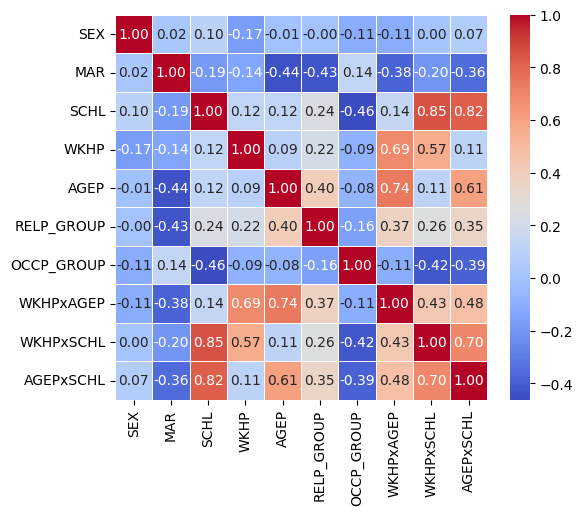

In [92]:
# Graphical: Feature Selection 3 - Pearson correlation heatmap on top-10 selected features
# Pearson(linear): Cross-validates Kendall results for linear multi-collinearity
vis_feats_corr = vis_feats_X.corr('pearson')
plt.figure(figsize=(6,5))
sbn.heatmap(vis_feats_corr, annot=True, linewidths=0.5, fmt='.2f', cmap='coolwarm')
plt.show()


In [93]:
# Fix Multi-Collinearity: Drop AGEP, WKHP, WKHPxSCHL, AGEPxSCHL (high inter-feature correlation)
# WKHPxAGEP retained as the most expressive interaction term
top_feats_X.drop(['AGEP', 'WKHP', 'WKHPxSCHL', 'AGEPxSCHL'], axis=1, inplace=True)


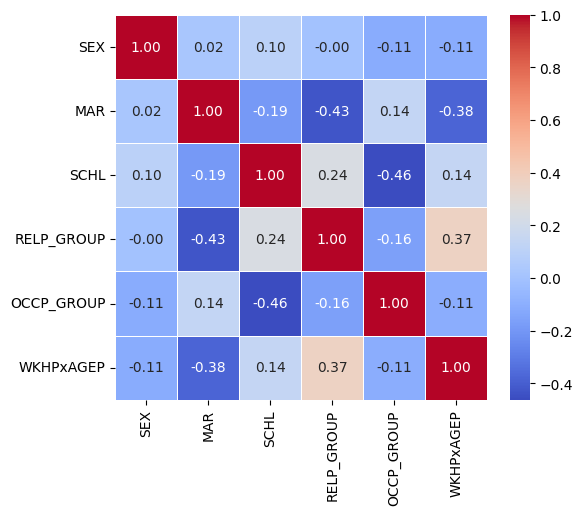

In [94]:
# Graphical: Feature Selection 4 - Pearson heatmap after multi-collinearity removal
# Verify remaining features show low inter-correlation before proceeding to train/test split
vis_feats_X = top_feats_X.loc[:, :]
vis_feats_corr = vis_feats_X.corr('pearson')
plt.figure(figsize=(6,5))
sbn.heatmap(vis_feats_corr, annot=True, linewidths=0.5, fmt='.2f', cmap='coolwarm')
plt.show()


In [95]:
# Training & Test Sets: ShuffleSplit (80/20 split, random_state=42 for reproducibility)
#Split training and test data
X = income_X.copy()
y = income_y.copy()

split = ShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in split.split(X):
    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]


In [96]:
# Fix P3f (Not applicable to the new dataset):
# The original 2018 ACS dataset frequency-encoded POBP (place of birth) after the train/test
# split. new_dataset.csv has no POBP column, so this step is skipped -- X_train / X_test from
# the previous cell already contain only the columns used for modeling.

In [97]:
# Textual: Confirm train/test split shapes before scaling
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)


(167220, 47) (41806, 47)
(167220,) (41806,)


In [98]:
# Feature Scaling: QuantileTransformer on continuous features AGEP and WKHP
# output_distribution='normal': maps skewed age/hours-worked distributions to normal(-1..0..+1)
# Fit ONLY on data(Train) to avoid 'data-leak' & 'bias' from data(Test)
#Normalize and Standardize regression features
from sklearn.preprocessing import QuantileTransformer
from sklearn.compose import ColumnTransformer

cols_to_transform = ['AGEP', 'WKHP']

quantile_trans = QuantileTransformer(
    output_distribution='normal',
    random_state=42
)
quantile_trans.fit(X_train[cols_to_transform])

stan_X_train = X_train.copy()
stan_X_test = X_test.copy()

# fit on training columns only
stan_X_train[cols_to_transform] = quantile_trans.transform(X_train[cols_to_transform])
stan_X_test[cols_to_transform] = quantile_trans.transform(X_test[cols_to_transform])


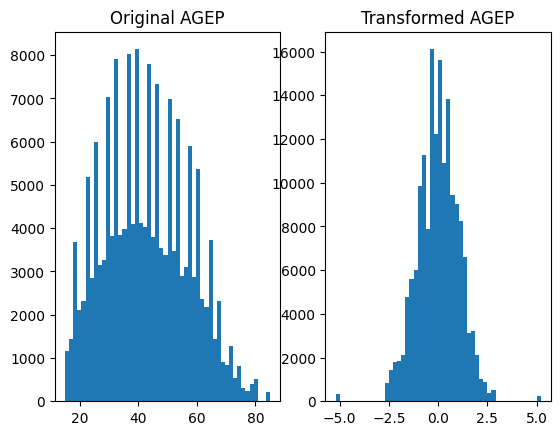

In [99]:
# Graphical: Feature Scaling Verification 1 - AGEP distribution before vs. after QuantileTransform
plt.figure()

plt.subplot(1, 2, 1)
plt.hist(X_train['AGEP'], bins=50)
plt.title("Original AGEP")

plt.subplot(1, 2, 2)
plt.hist(stan_X_train['AGEP'], bins=50)
plt.title("Transformed AGEP")

plt.show()


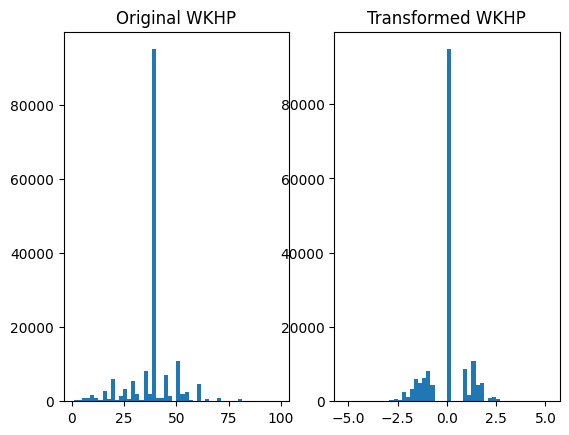

In [100]:
# Graphical: Feature Scaling Verification 2 - WKHP distribution before vs. after QuantileTransform
plt.figure()

plt.subplot(1, 2, 1)
plt.hist(X_train['WKHP'], bins=50)
plt.title("Original WKHP")

plt.subplot(1, 2, 2)
plt.hist(stan_X_train['WKHP'], bins=50)
plt.title("Transformed WKHP")

plt.show()


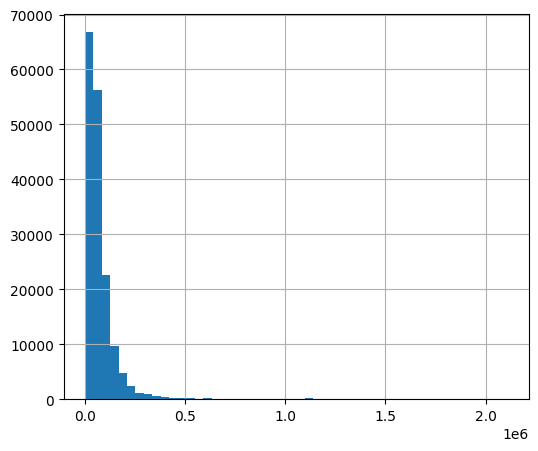

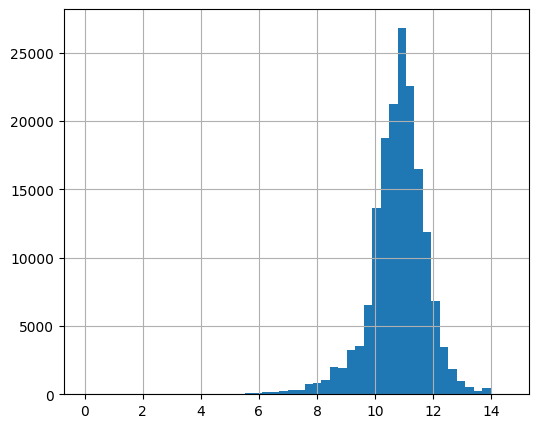

In [101]:
# Target Scaling: Apply log1p transform to PINCP (experimentally determined as best)
# log1p(y): handles zero incomes; reverses with expm1() during evaluation
# Histogram comparison confirms skewness reduction on log-transformed target
#apply logarithm to target — works best, tested experimentally
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)
y_train.hist(bins=50, figsize=(6,5))
plt.show()
y_train_log.hist(bins=50, figsize=(6, 5))
plt.show()


In [102]:
# Target Scaling: Z-Score Standardization (StandardScaler) on PINCP
# StandardScaler(): transforms target to standard normal distr. (-1..0..+1)
# Fit ONLY on data(Train) to avoid 'data-leak' & 'bias' from data(Test)
#Apply Z-Score Normalization

stdsc_y_scaler = StandardScaler()
stdsc_y_scaler = stdsc_y_scaler.fit(y_train.values.reshape(-1, 1))
standized_y_train = stdsc_y_scaler.transform(y_train.values.reshape(-1, 1))
standized_y_test = stdsc_y_scaler.transform(y_test.values.reshape(-1, 1))


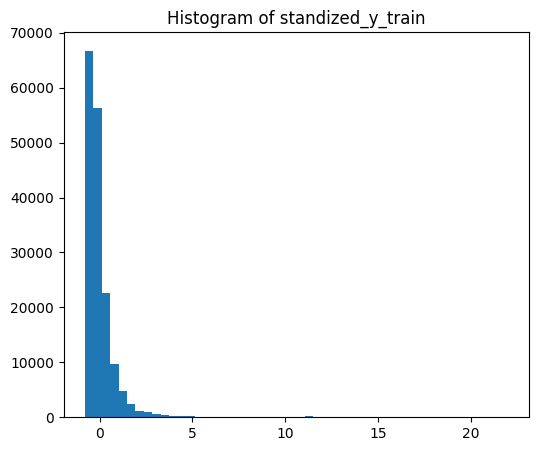

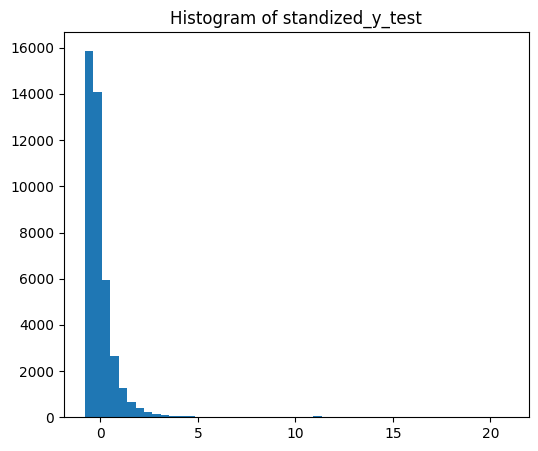

In [103]:
# Graphical: Target Scaling Verification - Histogram of standardized train/test targets
# Confirms that StandardScaler() output approximates normal(-1..0..+1) distribution
plt.figure(figsize=(6,5))
plt.hist(standized_y_train, bins=50)
plt.title('Histogram of standized_y_train')
plt.show()

plt.figure(figsize=(6,5))
plt.hist(standized_y_test, bins=50)
plt.title('Histogram of standized_y_test')
plt.show()


In [104]:
# Utility Function: regression_evaluation() - K-Fold Cross-Validation training metrics
# Inverts log1p transform (expm1) before computing MAE, RMSE, R^2 on original dollar scale
# scaler: optional inverse-transform hook for StandardScaler targets
#Cross Validation Training Metrics Function
def regression_evaluation(X_train, y_train, algorithm, k, scaler=None):
    y_true = np.asarray(y_train).reshape(-1)
    cv_preds = cross_val_predict(algorithm, X_train, y_true, cv=k, method='predict')
    cv_preds = np.asarray(cv_preds).reshape(-1)

    # If a scaler was used, inverse transform first
    if scaler is not None:
        cv_preds = scaler.inverse_transform(cv_preds.reshape(-1, 1)).reshape(-1)
        y_true = scaler.inverse_transform(y_true.reshape(-1, 1)).reshape(-1)

    #when log applied to target
    cv_preds = np.expm1(cv_preds)
    y_true = np.expm1(y_true)

    print("Prediction shape:", cv_preds.shape)

    mse = mean_squared_error(y_true, cv_preds)
    mae = mean_absolute_error(y_true, cv_preds)
    rmse = np.sqrt(mse)
    mape = mean_absolute_percentage_error(y_true, cv_preds)
    r2 = r2_score(y_true, cv_preds)
    evs = explained_variance_score(y_true, cv_preds)

    y_range = np.max(y_true) - np.min(y_true)
    y_std = np.std(y_true)

    eps = 1e-8  # Small epsilon to avoid divide-by-zero

    mae_01_range = mae / (y_range + eps)
    rmse_01_range = rmse / (y_range + eps)
    mse_01_range = mse / ((y_range ** 2) + eps)

    mae_01_std = mae / (y_std + eps)
    rmse_01_std = rmse / (y_std + eps)
    mse_01_std = mse / ((y_std ** 2) + eps)

    #print(f"MSE:  {mse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    #print(f"MAPE: {mape:.4f}")
    print(f"R^2:  {r2:.4f}")
    #print(f"EVS:  {evs:.4f}")


In [105]:
# Utility Function: testing_evaluation() - Final test-set evaluation on held-out data
# Fits model on X_train, predicts on X_test, inverts log1p then reports MAE, RMSE, R^2
# Overfitting(Train ERR << Test ERR); Underfitting(Train ERR >> Test ERR)
def testing_evaluation(X_train, X_test, y_train, y_test, algorithm, scaler=None):
  model = algorithm
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)

  # If a scaler was used, inverse transform first
  if scaler is not None:
      y_pred = scaler.inverse_transform(y_pred.reshape(-1, 1)).reshape(-1)
      y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1)

  y_pred = np.expm1(y_pred)
  y_test = np.expm1(y_test)

  mse = mean_squared_error(y_test, y_pred)
  mae = mean_absolute_error(y_test, y_pred)
  rmse = np.sqrt(mse)
  r2 = r2_score(y_test, y_pred)

  print(f"MAE:  {mae:.4f}")
  print(f"RMSE: {rmse:.4f}")
  print(f"R^2:  {r2:.4f}")

  return model


In [106]:
# Training: Baseline Algorithm Sweep via Cross-Validation (k=3)
# Epoch: 1 complete pass through entire data(Train). Iteration: no. of batches needed to complete 1 epoch.
# Log-transformed target (y_train_log) used; expm1() applied inside regression_evaluation()
algorithms = {
    "Ridge": Ridge(),
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    #"RandomForest": RandomForestRegressor(n_estimators=30, n_jobs=-1, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=50, verbosity=0, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=50, random_state=42, verbose=-1),
    "CatBoost": CatBoostRegressor(iterations=50, verbose=0, random_state=42),
}
for name, alg in algorithms.items():
  print(name, '\n')
  #nothing applied to target
  regression_evaluation(X_train, y_train_log, alg, 3)
  #testing_evaluation(X_train, X_test, y_train, y_test, alg)
  print('\n')


Ridge 

Prediction shape: (167220,)
MAE:  35006.0361
RMSE: 83216.0337
R^2:  0.1926


Linear Regression 

Prediction shape: (167220,)
MAE:  35006.0113
RMSE: 83215.5841
R^2:  0.1926


Lasso 

Prediction shape: (167220,)
MAE:  41731.9677
RMSE: 92405.2642
R^2:  0.0045


XGBoost 

Prediction shape: (167220,)
MAE:  33074.2440
RMSE: 81092.4582
R^2:  0.2333


LightGBM 

Prediction shape: (167220,)
MAE:  33144.1897
RMSE: 81807.2192
R^2:  0.2197


CatBoost 

Prediction shape: (167220,)
MAE:  33107.5789
RMSE: 81390.1977
R^2:  0.2277




In [107]:
# Evaluate: Test-Set Performance of Baseline Algorithms
# Overfitting(Train ERR << Test ERR); Underfitting(Train ERR >> Test ERR)
for name, alg in algorithms.items():
  print(name, '\n')
  #nothing applied to target
  #regression_evaluation(X_train, y_train, alg, 3)
  testing_evaluation(X_train, X_test, y_train_log, y_test_log, alg)
  print('\n')


Ridge 

MAE:  34725.2213
RMSE: 82219.4118
R^2:  0.2014


Linear Regression 

MAE:  34725.1910
RMSE: 82219.0422
R^2:  0.2014


Lasso 

MAE:  41467.8769
RMSE: 91543.1166
R^2:  0.0100


XGBoost 

MAE:  32824.3221
RMSE: 80082.1438
R^2:  0.2424


LightGBM 

MAE:  32962.6352
RMSE: 80824.3604
R^2:  0.2283


CatBoost 

MAE:  32864.5303
RMSE: 80350.9590
R^2:  0.2373




In [108]:
# Ensemble Training: train_ensemble() - XGBoost, LightGBM, CatBoost with early stopping
# All models trained on log1p(PINCP); early_stopping_rounds=100 via val_set
# Ensemble prediction = simple average of the three model outputs
def train_ensemble(X_train, y_train_log, X_val, y_val_log):
    """
    Train XGBoost, LightGBM, and CatBoost on log-transformed targets,
    then convert predictions back to original scale for evaluation.
    """
    import numpy as np
    from sklearn.metrics import mean_absolute_error, r2_score

    models = {}
    predictions = {}

    X_train_np = X_train.values if hasattr(X_train, 'values') else X_train
    X_val_np = X_val.values if hasattr(X_val, 'values') else X_val

    y_val = np.expm1(y_val_log)

    # ===== XGBoost Model =====
    print("Training XGBoost...")
    xgb_model = XGBRegressor(
        n_estimators=1200,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=10,
        objective="reg:squarederror",
        tree_method="hist",
        random_state=42,
        verbosity=0,
        early_stopping_rounds=100
    )

    xgb_model.fit(
        X_train_np, y_train_log,
        eval_set=[(X_val_np, y_val_log)],
        verbose=False
    )

    xgb_preds_log = xgb_model.predict(X_val_np)
    xgb_preds = np.expm1(xgb_preds_log)
    xgb_mae = mean_absolute_error(y_val, xgb_preds)
    xgb_r2 = r2_score(y_val, xgb_preds)
    print(f"XGBoost - MAE: {xgb_mae:.4f}, R²: {xgb_r2:.4f}")

    models['xgb'] = xgb_model
    predictions['xgb'] = xgb_preds

    # ===== LightGBM Model =====
    print("Training LightGBM...")
    lgb_model = LGBMRegressor(
        n_estimators=1200,
        learning_rate=0.1,
        max_depth=6,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=10,
        random_state=42,
        verbose=-1
    )

    lgb_model.fit(
        X_train_np, y_train_log,
        eval_set=[(X_val_np, y_val_log)],
        callbacks=[
            lgb.early_stopping(100),
            lgb.log_evaluation(0)
        ]
    )

    lgb_preds_log = lgb_model.predict(X_val_np)
    lgb_preds = np.expm1(lgb_preds_log)
    lgb_mae = mean_absolute_error(y_val, lgb_preds)
    lgb_r2 = r2_score(y_val, lgb_preds)
    print(f"LightGBM - MAE: {lgb_mae:.4f}, R²: {lgb_r2:.4f}")

    models['lgb'] = lgb_model
    predictions['lgb'] = lgb_preds

    # ===== CatBoost Model =====
    print("Training CatBoost...")
    cb_model = CatBoostRegressor(
        iterations=1200,
        learning_rate=0.1,
        depth=6,
        subsample=0.8,
        reg_lambda=10,
        random_state=42,
        verbose=0
    )

    cb_model.fit(
        X_train_np, y_train_log,
        eval_set=[(X_val_np, y_val_log)],
        early_stopping_rounds=100,
        verbose=False
    )

    cb_preds_log = cb_model.predict(X_val_np)
    cb_preds = np.expm1(cb_preds_log)
    cb_mae = mean_absolute_error(y_val, cb_preds)
    cb_r2 = r2_score(y_val, cb_preds)
    print(f"CatBoost - MAE: {cb_mae:.4f}, R²: {cb_r2:.4f}")

    models['catboost'] = cb_model
    predictions['catboost'] = cb_preds

    # ===== Ensemble Predictions =====
    ensemble_preds = (xgb_preds + lgb_preds + cb_preds) / 3
    #ensemble_preds = 0.3 * xgb_preds + 0.4 * lgb_preds + 0.3 * cb_preds
    ensemble_mae = mean_absolute_error(y_val, ensemble_preds)
    ensemble_r2 = r2_score(y_val, ensemble_preds)
    print(f"\nENSEMBLE (Average) - MAE: {ensemble_mae:.4f}, R²: {ensemble_r2:.4f}")
    print(f"Ensemble improvement over best single model: {ensemble_r2 - max(xgb_r2, lgb_r2, cb_r2):.4f} R² change")

    predictions['ensemble'] = ensemble_preds

    return models, predictions

In [109]:
# Ensemble Evaluation: final_test_evaluation() - Full test-set scoring across all models
# Reports MAE, R^2, RMSE, MAPE on original dollar scale after inverting log1p
# MAPE computed with nonzero_mask to guard against divide-by-zero on zero-income samples
def final_test_evaluation(models_dict, X_train, X_test, y_train_log, y_test_log):
    """
    Evaluates models when target was trained as log1p(y).
    Predictions and y_test are converted back to original dollar scale.
    """

    print("\n" + "="*80)
    print("FINAL TEST SET EVALUATION")
    print("="*80)

    X_test_np = X_test.values if hasattr(X_test, 'values') else X_test

    # Convert y_test back to original scale
    y_test_actual = np.expm1(y_test_log)

    def evaluate_model(model_name, model):
        print(f"Evaluating {model_name} on test set...")

        # Predict in log scale
        preds_log = model.predict(X_test_np)

        # Convert predictions back to original scale
        preds_actual = np.expm1(preds_log)

        mae = mean_absolute_error(y_test_actual, preds_actual)
        r2 = r2_score(y_test_actual, preds_actual)
        rmse = np.sqrt(mean_squared_error(y_test_actual, preds_actual))

        # safer MAPE to avoid divide-by-zero issues
        nonzero_mask = y_test_actual != 0
        mape = np.mean(
            np.abs(
                (y_test_actual[nonzero_mask] - preds_actual[nonzero_mask])
                / y_test_actual[nonzero_mask]
            )
        )

        return preds_actual, mae, r2, rmse, mape

    xgb_preds, xgb_mae, xgb_r2, xgb_rmse, xgb_mape = evaluate_model(
        "XGBoost", models_dict['xgb']
    )

    lgb_preds, lgb_mae, lgb_r2, lgb_rmse, lgb_mape = evaluate_model(
        "LightGBM", models_dict['lgb']
    )

    cb_preds, cb_mae, cb_r2, cb_rmse, cb_mape = evaluate_model(
        "CatBoost", models_dict['catboost']
    )

    print("Evaluating ENSEMBLE on test set...")

    # ensemble in ORIGINAL scale
    ensemble_preds = (xgb_preds + lgb_preds + cb_preds) / 3
    #ensemble_preds = 0.3 * xgb_preds + 0.4 * lgb_preds + 0.3 * cb_preds

    ensemble_mae = mean_absolute_error(y_test_actual, ensemble_preds)
    ensemble_r2 = r2_score(y_test_actual, ensemble_preds)
    ensemble_rmse = np.sqrt(mean_squared_error(y_test_actual, ensemble_preds))

    nonzero_mask = y_test_actual != 0
    ensemble_mape = np.mean(
        np.abs(
            (y_test_actual[nonzero_mask] - ensemble_preds[nonzero_mask])
            / y_test_actual[nonzero_mask]
        )
    )

    test_results = {
        'Model': ['XGBoost', 'LightGBM', 'CatBoost', 'Ensemble'],
        'MAE': [xgb_mae, lgb_mae, cb_mae, ensemble_mae],
        'R²': [xgb_r2, lgb_r2, cb_r2, ensemble_r2],
        'RMSE': [xgb_rmse, lgb_rmse, cb_rmse, ensemble_rmse],
        'MAPE': [xgb_mape, lgb_mape, cb_mape, ensemble_mape]
    }

    summary_df = pd.DataFrame(test_results)

    print("\n" + "="*80)
    print("TEST SET RESULTS — ORIGINAL TARGET SCALE")
    print("="*80)
    print(summary_df.to_string(index=False))
    print("="*80)

    return test_results, summary_df

In [110]:
# Training Ensemble Models: XGBoost, LightGBM, CatBoost on 80/20 train/val split
# 'mdl_history' equivalent: models_dict stores trained models; val_predictions stores val outputs
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train_log, test_size=0.2, random_state=42)

models_dict, val_predictions = train_ensemble(X_tr, y_tr, X_val, y_val)


Training XGBoost...
XGBoost - MAE: 32835.0871, R²: 0.2421
Training LightGBM...
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[476]	valid_0's l2: 0.489218
LightGBM - MAE: 32806.5278, R²: 0.2444
Training CatBoost...


c:\Users\Jonathan\Documents\School\CSC 180\Project_Echo2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


CatBoost - MAE: 32836.5533, R²: 0.2402

ENSEMBLE (Average) - MAE: 32779.8830, R²: 0.2428
Ensemble improvement over best single model: -0.0016 R² change


In [111]:
# Evaluate: Final Test-Set Results for Ensemble and Individual Models
# Overfitting(Train ERR << Test ERR); Underfitting(Train ERR >> Test ERR)
test_results_final, summary_table = final_test_evaluation(
    models_dict, X_tr, X_test, y_tr, y_test_log
)



FINAL TEST SET EVALUATION
Evaluating XGBoost on test set...
Evaluating LightGBM on test set...
Evaluating CatBoost on test set...
Evaluating ENSEMBLE on test set...

TEST SET RESULTS — ORIGINAL TARGET SCALE
   Model          MAE       R²         RMSE     MAPE
 XGBoost 32695.955547 0.243754 80008.434148 4.327904
LightGBM 32706.583113 0.244538 79966.987211 3.996386
CatBoost 32665.227676 0.242833 80057.140705 4.356041
Ensemble 32647.613511 0.244312 79978.911470 4.225962


c:\Users\Jonathan\Documents\School\CSC 180\Project_Echo2\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


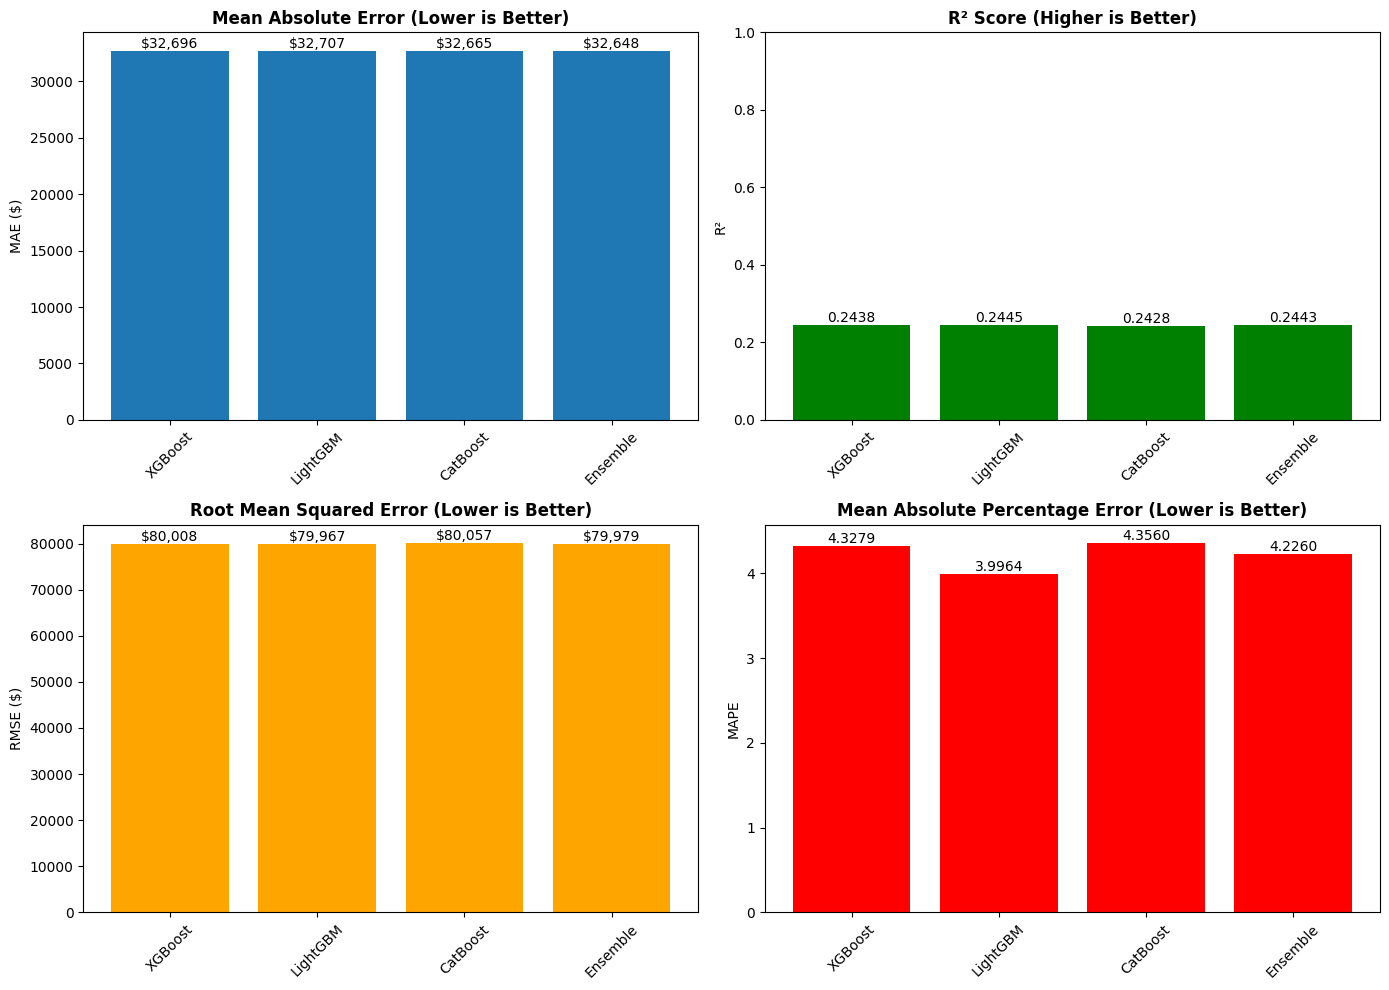

✓ Model performance comparison chart displayed


In [112]:
# Learning Curve: Plot performance of ensemble models wrt. MAE, R^2, RMSE, MAPE
# 4-panel bar chart comparing XGBoost, LightGBM, CatBoost, and Ensemble on test set

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: MAE Comparison
axes[0, 0].bar(summary_table['Model'], summary_table['MAE'])
axes[0, 0].set_title('Mean Absolute Error (Lower is Better)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('MAE ($)')
axes[0, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(summary_table['MAE']):
    axes[0, 0].text(i, v, f'${v:,.0f}', ha='center', va='bottom')

# Plot 2: R² Comparison
axes[0, 1].bar(summary_table['Model'], summary_table['R²'], color='green')
axes[0, 1].set_title('R² Score (Higher is Better)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('R²')
axes[0, 1].set_ylim([0, 1])
axes[0, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(summary_table['R²']):
    axes[0, 1].text(i, v, f'{v:.4f}', ha='center', va='bottom')

# Plot 3: RMSE Comparison
axes[1, 0].bar(summary_table['Model'], summary_table['RMSE'], color='orange')
axes[1, 0].set_title('Root Mean Squared Error (Lower is Better)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('RMSE ($)')
axes[1, 0].tick_params(axis='x', rotation=45)
for i, v in enumerate(summary_table['RMSE']):
    axes[1, 0].text(i, v, f'${v:,.0f}', ha='center', va='bottom')

# Plot 4: MAPE Comparison
axes[1, 1].bar(summary_table['Model'], summary_table['MAPE'], color='red')
axes[1, 1].set_title('Mean Absolute Percentage Error (Lower is Better)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('MAPE')
axes[1, 1].tick_params(axis='x', rotation=45)
for i, v in enumerate(summary_table['MAPE']):
    axes[1, 1].text(i, v, f'{v:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("✓ Model performance comparison chart displayed")


In [113]:
# Save Model Pipeline: Persist trained models and all preprocessing encoders via joblib
# Artifact contains: models dict, scaler columns, ordinal encoders, feature columns
# Load with: artifact = joblib.load('income_pipeline.pkl')
# NOTE: POBP frequency map removed -- new_dataset.csv has no POBP column.
import joblib

artifact = {
    "models": models_dict,
    "cols_to_transform": cols_to_transform,  # AGEP, WKHP - columns passed through QuantileTransformer
    "relp_ordinal_encoder": ordinal_relp,
    "race_ordinal_encoder": ordinal_race,
    "occp_ordinal_encoder": ordinal,
    "feature_columns": X_train.columns.tolist(),
    "relp_categories": relp_order,
    "race_categories": race_order,
    "occp_categories": ordinal.categories_
}
joblib.dump(artifact, "income_pipeline.pkl")

['income_pipeline.pkl']